# Этап 1

## Задача

### Построение рекуррентной нейронной сети для распознавания эмоциональной окраски отзывов из базы данных IMDB

Целью данного этапа лабораторной работы является создание рекуррентного
бинарного классификатора эмоциональной окраски отзывов из набора
данных IMDB. Пошаговая реализация поставленной цели включает:
1. Загрузку набора данных IMDB;
2. Создание векторного представления слов из набора данных;
3. Разделение данных на обучающий и тестовый наборы;
4. Подготовку данных для передачи в нейронную сеть;
5. Конструирование сети: создание сети из слоя Embedding и
рекуррентных слоев заданного типа в соответствии с вариантом;
6. Настройку оптимизатора с выбором функции потерь и метрики
качества. Число эпох принять от 30 до 60;
7. Проведение проверки решения, выделяя контрольное множество;
8. Вывод графиков функции потерь и точности;
9. Использование обученной сети для предсказания на новых данных;
10. Сопоставление полученных результатов с одномерной сверточной сетью (три сверточных слоя)

## Вариант

### №2
* Количество рекуррентных слоев: **1**
* Размерность векторного представления: **32**
* Количество нейронов на слое: **64**
* Рекуррентный слой: **LSTM**

## Решение

### Шаг 0: подготовка

#### Импорт библиотек

In [25]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import ssl

#### Инициализация констант

In [26]:
words_count, maxlen = 8000, 500
train_size, test_size = 10000, 1000
epochs, batch_size = 30, 128

### Шаг 1: загрузка набора данных IMDB

#### Загрузка датасета

In [27]:
ssl._create_default_https_context = ssl._create_unverified_context
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=words_count)
ssl._create_default_https_context = ssl.create_default_context

### Шаг 2: создание векторного представления слов

In [28]:
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

### Шаг 3: разделение данных на тренировочную, валидационную и тестовую выборки

#### Выделение части выборки
Для того, чтобы ускорить обучение

In [29]:
x_train, y_train = x_train[:train_size], y_train[:train_size]
x_test, y_test = x_test[:test_size], y_test[:test_size]

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=40)

print(f"Размер обучающей выборки: {x_train.shape}")
print(f"Размер валидационной выборки: {x_val.shape}")
print(f"Размер тестовой выборки: {x_test.shape}")

Размер обучающей выборки: (8000, 500)
Размер валидационной выборки: (2000, 500)
Размер тестовой выборки: (1000, 500)


### Шаг 4: предобработка данных
Выполнялся в рамках шага 2

### Шаг 5: конструирование сети

In [33]:
model_rnn = keras.Sequential([
    layers.Embedding(input_dim=words_count, output_dim=32, input_length=maxlen),
    layers.LSTM(64),
    layers.Dense(1, activation='sigmoid')
])

model_rnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Шаг 6: настройка модели

In [34]:
model_rnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#### Обучение модели

In [35]:
history_rnn = model_rnn.fit(
    x_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(x_val, y_val),
    verbose=1
)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 187ms/step - accuracy: 0.6149 - loss: 0.6652 - val_accuracy: 0.7115 - val_loss: 0.6158
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 185ms/step - accuracy: 0.8081 - loss: 0.4437 - val_accuracy: 0.8580 - val_loss: 0.3473
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 185ms/step - accuracy: 0.8992 - loss: 0.2639 - val_accuracy: 0.8605 - val_loss: 0.3316
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 182ms/step - accuracy: 0.9342 - loss: 0.1830 - val_accuracy: 0.8660 - val_loss: 0.3405
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 189ms/step - accuracy: 0.9484 - loss: 0.1533 - val_accuracy: 0.8560 - val_loss: 0.3731
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 200ms/step - accuracy: 0.9643 - loss: 0.1111 - val_accuracy: 0.8385 - val_loss: 0.4185
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 187ms/step - accuracy: 0.9707 - loss: 0.0914 - val_accuracy: 0.8585 - val_loss: 0.4771
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 198ms/step - accuracy: 0.9806 - loss: 0.0670 - val_accu

### 

### Шаг 7: проверка модели на контрольном множестве

In [36]:
test_loss, test_acc = model_rnn.evaluate(x_test, y_test, verbose=0)
print(f"Точность на тестовых данных: {test_acc:.4f}")

Точность на тестовых данных: 0.8410


### Шаг 8: вывод графиков функции потерь и точности

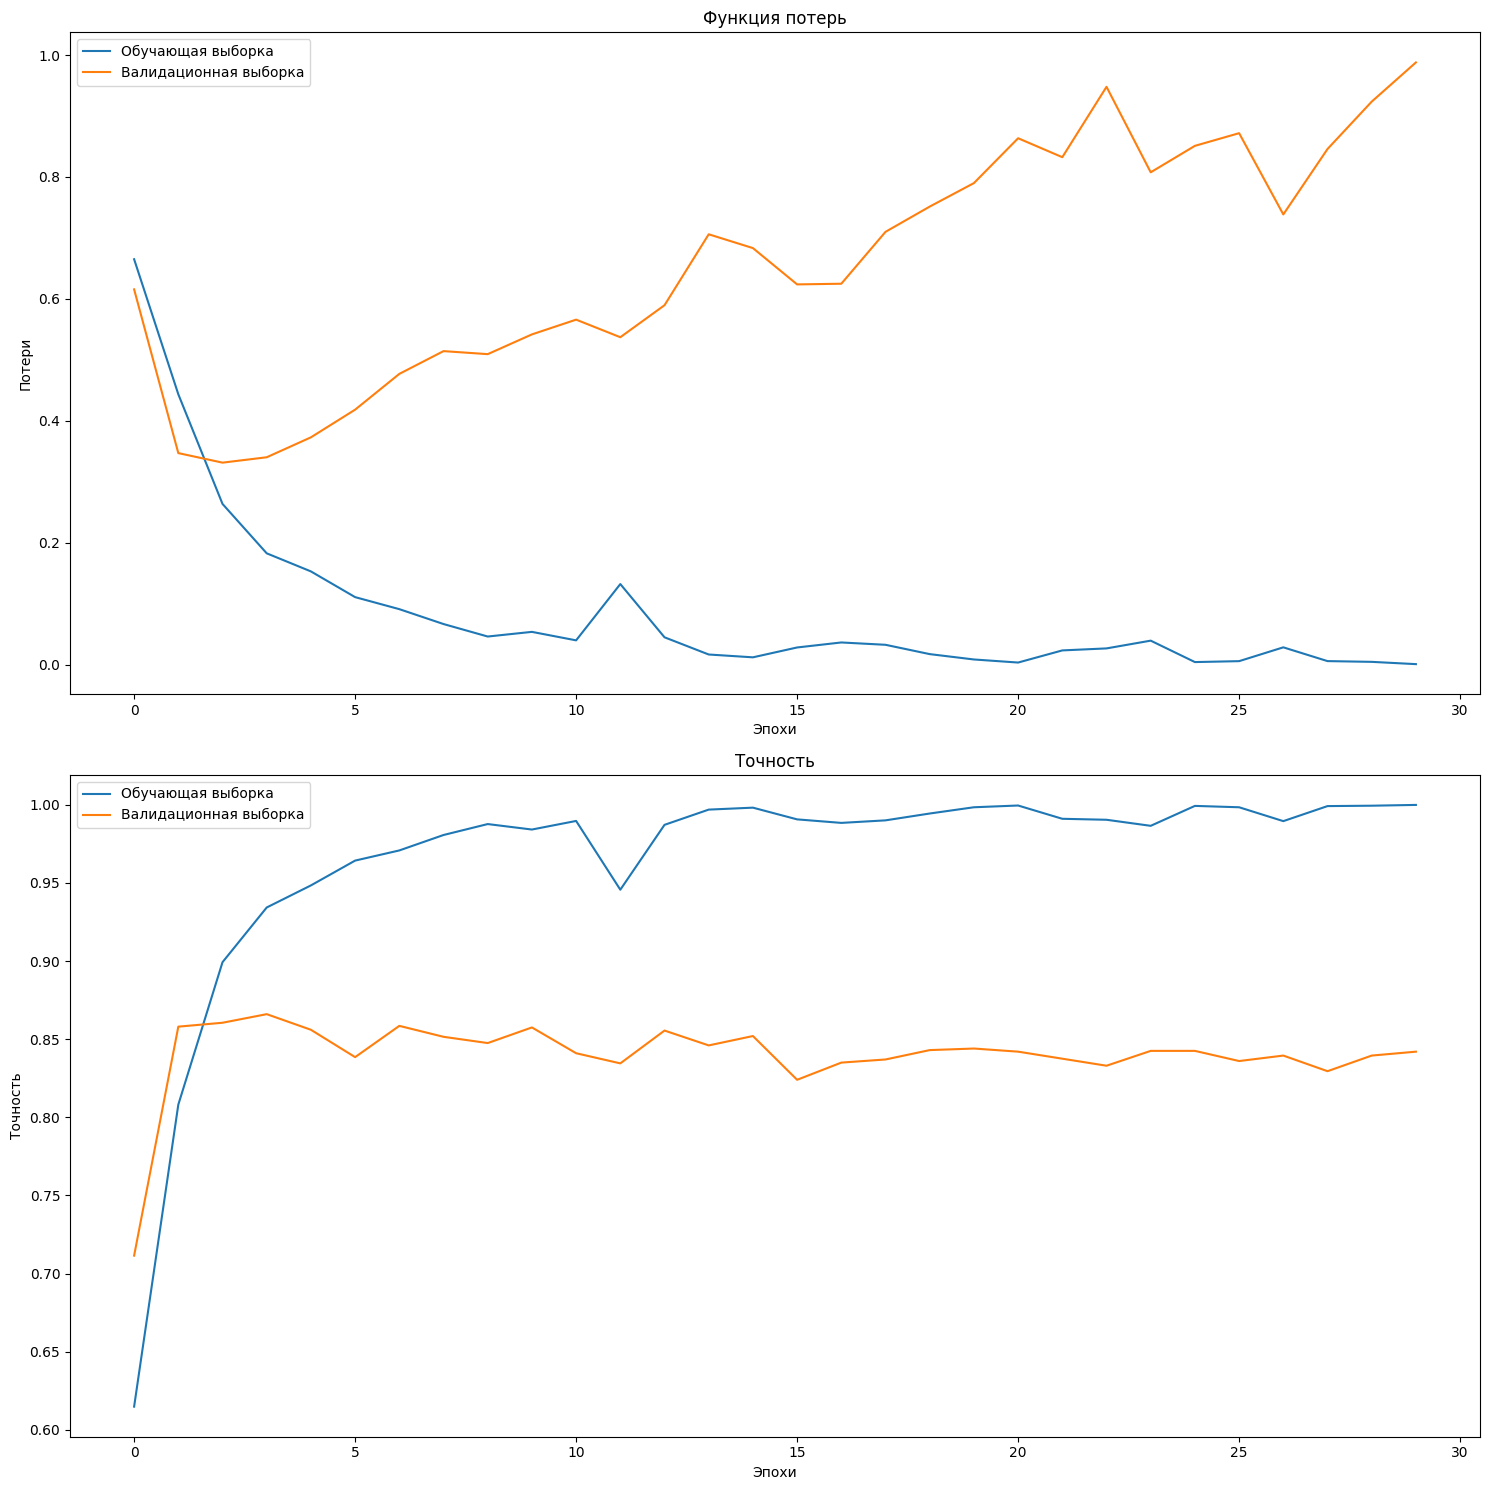

In [46]:
plt.figure(figsize=(15, 15))

plt.subplot(2, 1, 1)
plt.plot(history_rnn.history['loss'], label='Обучающая выборка')
plt.plot(history_rnn.history['val_loss'], label='Валидационная выборка')
plt.title('Функция потерь')
plt.xlabel('Эпохи')
plt.ylabel('Потери')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(history_rnn.history['accuracy'], label='Обучающая выборка')
plt.plot(history_rnn.history['val_accuracy'], label='Валидационная выборка')
plt.title('Точность')
plt.xlabel('Эпохи')
plt.ylabel('Точность')
plt.legend()

plt.tight_layout()
plt.show()

### Шаг 9: использование обученной сети для предсказания на новых данных

In [58]:
def predict_sentiment(text_sample_indices):
    """Функция для предсказания эмоциональной окраски"""
    sample_text = decode_review(text_sample_indices)
    print(f"Текст отзыва:\n ...{sample_text[-300:]}")

    sample_processed = keras.preprocessing.sequence.pad_sequences([text_sample_indices], maxlen=maxlen)

    prediction = model_rnn.predict(sample_processed, verbose=0)
    sentiment = "Позитивный" if prediction[0][0] > 0.5 else "Негативный"
    print(f"Предсказание: окраска {sentiment.lower()[:-2]+'ая'}")
    print("-" * 50)
    print("\n")

sample_indices = x_test[:4]
for i, sample in enumerate(sample_indices):
    predict_sentiment(sample)

Текст отзыва:
 ...<UNK> and the rest of the cast rendered terrible performances the show is flat flat flat br br i don't know how michael madison could have allowed this one on his plate he almost seemed to know this wasn't going to work out and his performance was quite <UNK> so all you madison fans give this a miss
Предсказание: окраска негативная
--------------------------------------------------


Текст отзыва:
 ...er this film is disturbing but it's sincere and it's sure to <UNK> a strong emotional response from the viewer if you want to see an unusual film some might even say bizarre this is worth the time br br unfortunately it's very difficult to find in video stores you may have to buy it off the internet
Предсказание: окраска позитивная
--------------------------------------------------


Текст отзыва:
 ...choice of material the film stands as a <UNK> tale of universal <UNK> <UNK> could be the soviet union italy germany or japan in the 1930s or any country of any era that let

### Шаг 10: Сопоставление полученных результатов с одномерной сверточной сетью

In [40]:
model_cnn = keras.Sequential([
    layers.Embedding(input_dim=words_count, output_dim=32, input_length=maxlen),
    layers.Conv1D(32, 5, activation='relu'),
    layers.GlobalMaxPooling1D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model_cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [41]:
history_cnn = model_cnn.fit(
    x_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(x_val, y_val),
    verbose=1
)

cnn_test_loss, cnn_test_acc = model_cnn.evaluate(x_test, y_test, verbose=1)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5311 - loss: 0.6902 - val_accuracy: 0.6355 - val_loss: 0.6778
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7040 - loss: 0.6067 - val_accuracy: 0.7335 - val_loss: 0.5241
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7994 - loss: 0.4576 - val_accuracy: 0.7915 - val_loss: 0.4353
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8844 - loss: 0.3133 - val_accuracy: 0.8425 - val_loss: 0.3608
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9498 - loss: 0.1776 - val_accuracy: 0.8575 - val_loss: 0.3398
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9811 - loss: 0.0890 - val_accuracy: 0.8605 - val_loss: 0.3484
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9945 - loss: 0.0432 - val_accuracy: 0.8540 - val_loss: 0.3559
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9989 - loss: 0.0225 - val_accuracy: 0.8590 - v

In [59]:
print(f"RNN модель:")
print(f"Точность на тестовых данных: {test_acc}")

print(f"\nCNN модель:")
print(f"Точность на тестовых данных: {cnn_test_acc}")

RNN модель:
Точность на тестовых данных: 0.8410000205039978

CNN модель:
Точность на тестовых данных: 0.8500000238418579


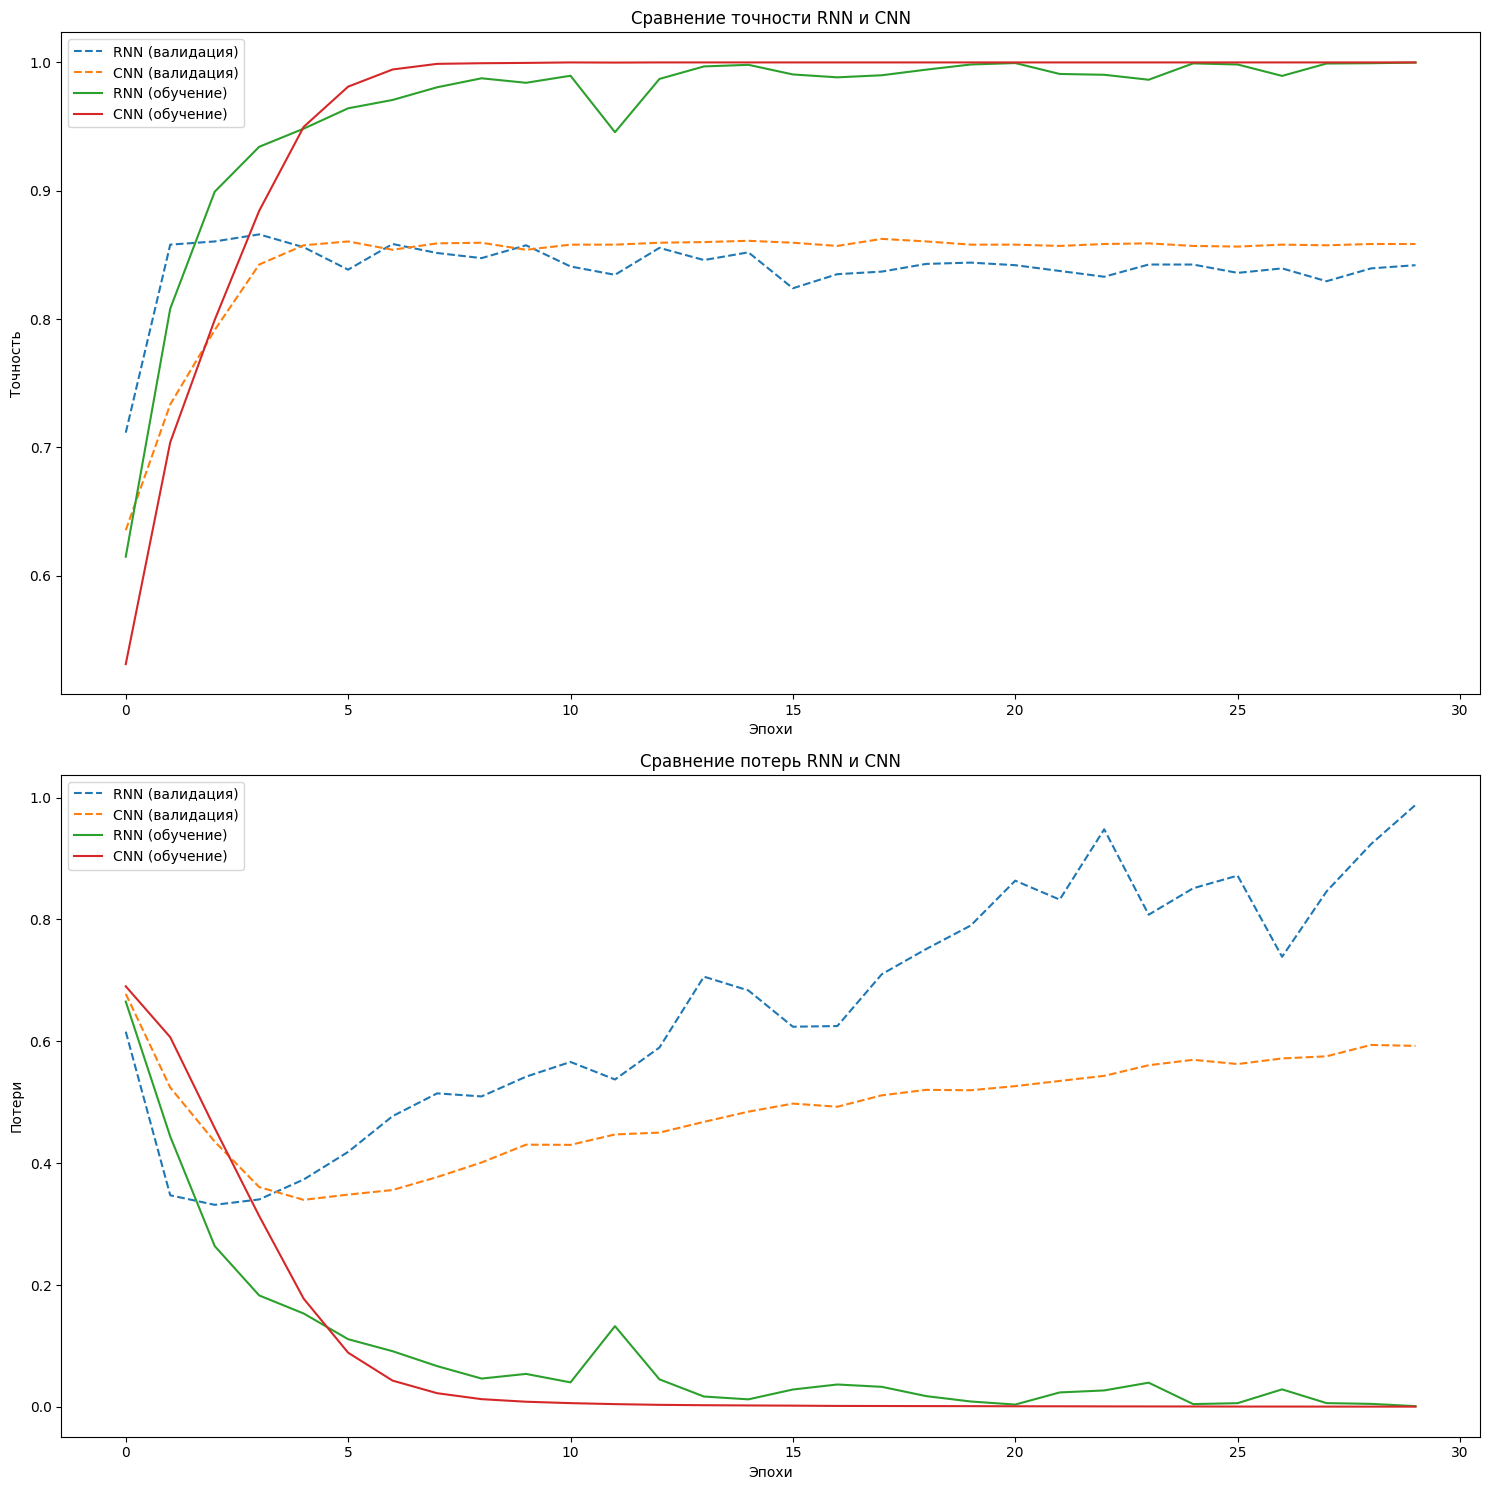

In [45]:
plt.figure(figsize=(15, 15))

plt.subplot(2, 1, 1)
plt.plot(history_rnn.history['val_accuracy'], label='RNN (валидация)', linestyle='--')
plt.plot(history_cnn.history['val_accuracy'], label='CNN (валидация)', linestyle='--')
plt.plot(history_rnn.history['accuracy'], label='RNN (обучение)')
plt.plot(history_cnn.history['accuracy'], label='CNN (обучение)')
plt.title('Сравнение точности RNN и CNN')
plt.xlabel('Эпохи')
plt.ylabel('Точность')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(history_rnn.history['val_loss'], label='RNN (валидация)', linestyle='--')
plt.plot(history_cnn.history['val_loss'], label='CNN (валидация)', linestyle='--')
plt.plot(history_rnn.history['loss'], label='RNN (обучение)')
plt.plot(history_cnn.history['loss'], label='CNN (обучение)')
plt.title('Сравнение потерь RNN и CNN')
plt.xlabel('Эпохи')
plt.ylabel('Потери')
plt.legend()

plt.tight_layout()
plt.show()

## Вывод

Хоть рекуррентная модель обучалась и дольше, но она показала худшие результаты по сравнению с одномерной сверточной сетью

Рекуррентная сеть на первых 3х эпохах обучалась хорошо, потери на валидации падали, а затем начали быстро расти. CNN тоже в какой-то момент начала переобучаться, но делала это медленнее